# 📧 Spam Email Detection — Exploratory Data Analysis
**Dataset:** SpamAssassin  |  **Target:** `target` (0 = Ham, 1 = Spam)

In [36]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils.logger import logger
from src.data_access.load_data import LoadData

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

logger.info("🚀 EDA Started")

# ─────────────────────────────────────────
# Load Data
# ─────────────────────────────────────────
logger.info("📥 Loading data from CSV: data/emails.csv")

load_obj = LoadData()
df = load_obj.fetch_and_save(file_path="data/emails.csv")

logger.info(f"✅ Data Loaded Successfully | Shape: {df.shape}")

[ 2026-05-15 03:28:55,276 ] [ INFO ] [ 3836518035.py:25 ] 🚀 🚀 EDA Started
[ 2026-05-15 03:28:55,277 ] [ INFO ] [ 3836518035.py:30 ] 🚀 📥 Loading data from CSV: data/emails.csv
[ 2026-05-15 03:28:55,279 ] [ INFO ] [ load_data.py:19 ] 🚀 ✅ LoadData class initialized
[ 2026-05-15 03:28:55,279 ] [ INFO ] [ load_data.py:124 ] 🚀 🔄 Starting fetch-and-save pipeline
[ 2026-05-15 03:28:55,280 ] [ INFO ] [ load_data.py:43 ] 🚀 📥 Fetching data from table: emails
[ 2026-05-15 03:28:55,280 ] [ INFO ] [ load_data.py:28 ] 🚀 🔌 Creating PostgreSQL connection
[ 2026-05-15 03:28:55,285 ] [ INFO ] [ load_data.py:30 ] 🚀 ✅ PostgreSQL connection established
[ 2026-05-15 03:28:55,401 ] [ INFO ] [ load_data.py:49 ] 🚀 ✅ Successfully fetched 5796 rows
[ 2026-05-15 03:28:55,401 ] [ INFO ] [ load_data.py:50 ] 🚀 📊 Data shape: (5796, 2)
[ 2026-05-15 03:28:55,402 ] [ INFO ] [ load_data.py:67 ] 🚀 💾 Saving dataframe to CSV
[ 2026-05-15 03:28:55,646 ] [ INFO ] [ load_data.py:87 ] 🚀 ✅ CSV saved successfully at: /Users/kaushi

## 1. Load & Parse Dataset

In [37]:
logger.info("🔍 Dataset Quick Check")
print(f'Shape: {df.shape}')
print(f'Duplicates: {df.duplicated().sum()}')
logger.info(f"Shape: {df.shape} | Duplicates: {df.duplicated().sum()}")
df.head(3)


[ 2026-05-15 03:28:55,652 ] [ INFO ] [ 3534438864.py:1 ] 🚀 🔍 Dataset Quick Check
[ 2026-05-15 03:28:55,812 ] [ INFO ] [ 3534438864.py:4 ] 🚀 Shape: (5796, 2) | Duplicates: 467


Shape: (5796, 2)
Duplicates: 467


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1


In [38]:
logger.info("📋 Column Names")
print(df.columns.tolist())


[ 2026-05-15 03:28:55,819 ] [ INFO ] [ 2502715857.py:1 ] 🚀 📋 Column Names


['text', 'target']


In [39]:
logger.info("📧 Email Parsing Started")

# ── Email Parsing ──────────────────────────────────────────────────────
HEADER_KEYS_RE = re.compile(
    r'\b(From|Return-Path|Delivered-To|Received|Message-Id|To|Subject|Date|'
    r'MIME-Version|Content-Type|Content-Transfer-Encoding|Delivery-Date|'
    r'Reply-To|Cc|Bcc|In-Reply-To|References|Importance|Thread-Index|'
    r'Thread-Topic|Organization|X-[\w-]+):\s*',
    re.IGNORECASE
)

def extract_body(text):
    matches = list(HEADER_KEYS_RE.finditer(text))
    if not matches:
        return text
    last_match = matches[-1]
    after_last = text[last_match.end():]
    value_end  = re.search(r'\s+[A-Z][^:]{10,}', after_last)
    body       = after_last[value_end.start():].strip() if value_end else after_last.strip()
    body       = HEADER_KEYS_RE.sub(' ', body)
    body       = re.sub(r'<[^>]+>', ' ', body)
    body       = re.sub(r'http\S+', ' ', body)
    body       = re.sub(r'\s+', ' ', body).strip()
    return body

def parse_email_regex(text):
    def get_field(pattern):
        match = re.search(pattern, text, re.IGNORECASE)
        return match.group(1).strip() if match else ''
    return {
        'from'   : get_field(r'From:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'subject': get_field(r'Subject:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'date'   : get_field(r'Date:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'to'     : get_field(r'To:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'body'   : extract_body(text)
    }

parsed        = df['text'].apply(parse_email_regex)
df['from']    = parsed.apply(lambda x: x['from'])
df['subject'] = parsed.apply(lambda x: x['subject'])
df['date']    = parsed.apply(lambda x: x['date'])
df['to']      = parsed.apply(lambda x: x['to'])
df['body']    = parsed.apply(lambda x: x['body'])

logger.info("✅ Email Parsing Completed")


# ─────────────────────────────────────────
    # Domain Features
# ─────────────────────────────────────────
logger.info("🌐 Domain Feature Engineering Started")

df['from_email']  = df['from'].str.extract(r'<?([\w\.\+\-]+@[\w\.\-]+\.\w+)>?')
df['from_domain'] = df['from_email'].str.extract(r'@([\w\.\-]+)')
df['to_email']    = df['to'].str.extract(r'<?([\w\.\+\-]+@[\w\.\-]+\.\w+)>?')
df['to_domain'] = df['to_email'].str.extract(r'@([\w\.\-]+)')
df['same_domain'] = (df['from_domain'] == df['to_domain']).astype(int)
df['to_is_generic'] = df['to_email'].str.contains(
    r'yyyy|localhost|noreply|admin|no-reply', case=False, na=False).astype(int)

logger.info("✅ Domain Features Completed")

# ─────────────────────────────────────────
# Date Features
# ─────────────────────────────────────────
logger.info("📅 Date Feature Engineering Started")

df['day_of_week'] = df['date'].str.extract(r'^(Mon|Tue|Wed|Thu|Fri|Sat|Sun)', expand=False)
df['is_weekend']  = df['day_of_week'].isin(['Sat', 'Sun']).astype(int)

logger.info("✅ Date Features Completed")

# ─────────────────────────────────────────
# Remove Duplicates
# ─────────────────────────────────────────
logger.info("🧹 Removing Duplicates")

df = df.drop_duplicates(subset=['subject', 'body'])
for col in ['to_email','to_domain','from_email','from_domain']:
    df[col].fillna('unknown', inplace=True)

print(f'After dedup shape: {df.shape}')
df.head(2)

logger.info(
        f"✅ Duplicates Removed | Shape: {df.shape}"
    )

[ 2026-05-15 03:28:55,828 ] [ INFO ] [ 584170930.py:1 ] 🚀 📧 Email Parsing Started
[ 2026-05-15 03:28:58,475 ] [ INFO ] [ 584170930.py:45 ] 🚀 ✅ Email Parsing Completed
[ 2026-05-15 03:28:58,476 ] [ INFO ] [ 584170930.py:51 ] 🚀 🌐 Domain Feature Engineering Started
[ 2026-05-15 03:28:58,497 ] [ INFO ] [ 584170930.py:61 ] 🚀 ✅ Domain Features Completed
[ 2026-05-15 03:28:58,498 ] [ INFO ] [ 584170930.py:66 ] 🚀 📅 Date Feature Engineering Started
[ 2026-05-15 03:28:58,500 ] [ INFO ] [ 584170930.py:71 ] 🚀 ✅ Date Features Completed
[ 2026-05-15 03:28:58,500 ] [ INFO ] [ 584170930.py:76 ] 🚀 🧹 Removing Duplicates
[ 2026-05-15 03:28:58,525 ] [ INFO ] [ 584170930.py:85 ] 🚀 ✅ Duplicates Removed | Shape: (5163, 15)


After dedup shape: (5163, 15)


## 2. Dataset Overview

In [40]:
logger.info("📊 Dataset Overview")
print('='*50)
print(f'Total emails   : {len(df):,}')
print(f'Columns        : {df.shape[1]}')
missing = df.isnull().sum()[df.isnull().sum() > 0]
print(f'Missing values :\n{missing}')
print('='*50)
df.info()
logger.info(f"Missing value columns: {missing.index.tolist() if len(missing) else 'None'}")


[ 2026-05-15 03:28:58,530 ] [ INFO ] [ 4120639862.py:1 ] 🚀 📊 Dataset Overview
[ 2026-05-15 03:28:58,542 ] [ INFO ] [ 4120639862.py:9 ] 🚀 Missing value columns: ['day_of_week']


Total emails   : 5,163
Columns        : 15
Missing values :
day_of_week    269
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 5163 entries, 0 to 5795
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           5163 non-null   object
 1   target         5163 non-null   int64 
 2   from           5163 non-null   object
 3   subject        5163 non-null   object
 4   date           5163 non-null   object
 5   to             5163 non-null   object
 6   body           5163 non-null   object
 7   from_email     5163 non-null   object
 8   from_domain    5163 non-null   object
 9   to_email       5163 non-null   object
 10  to_domain      5163 non-null   object
 11  same_domain    5163 non-null   int64 
 12  to_is_generic  5163 non-null   int64 
 13  day_of_week    4894 non-null   object
 14  is_weekend     5163 non-null   int64 
dtypes: int64(4), object(11)
memory usage: 645.4+ KB


## 3. Target Distribution (Ham vs Spam)

[ 2026-05-15 03:28:58,548 ] [ INFO ] [ 358357721.py:1 ] 🚀 📊 Plotting Target Distribution (Ham vs Spam)


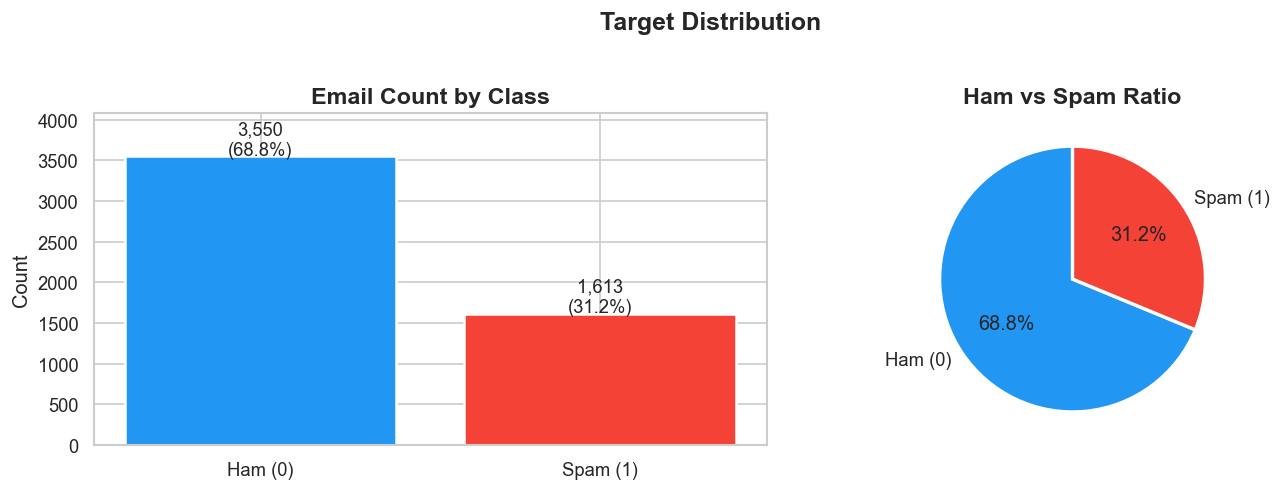

[ 2026-05-15 03:28:58,638 ] [ INFO ] [ 358357721.py:26 ] 🚀 Class balance — Ham: 3,550 | Spam: 1,613 | Ratio: 2.20:1


Class balance ratio (Ham:Spam) = 2.20:1


In [41]:
logger.info("📊 Plotting Target Distribution (Ham vs Spam)")
counts = df['target'].value_counts()
labels = ['Ham (0)', 'Spam (1)']
colors = ['#2196F3', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Email Count by Class')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Ham vs Spam Ratio')

plt.suptitle('Target Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Class balance ratio (Ham:Spam) = {counts[0]/counts[1]:.2f}:1')
logger.info(f"Class balance — Ham: {counts.get(0, 0):,} | Spam: {counts.get(1, 0):,} | Ratio: {counts.get(0,0)/max(counts.get(1,1),1):.2f}:1")


## 4. Text Feature Engineering

In [42]:
logger.info("🔧 Text Feature Engineering Started")
df['body_len']        = df['body'].str.len()
df['subject_len']     = df['subject'].str.len()
df['num_links']       = df['body'].str.count('http')
df['num_digits']      = df['body'].str.count(r'\d')
df['num_exclaim']     = df['body'].str.count('!') + df['subject'].str.count('!')
df['num_dollar']      = df['body'].str.count('\$') + df['subject'].str.count('\$')
df['caps_ratio']      = df['body'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))
df['num_question']    = df['body'].str.count('\?')
df['has_link']        = (df['num_links'] > 0).astype(int)
df['has_free']        = df['body'].str.lower().str.contains('free', na=False).astype(int)
df['has_win']         = df['body'].str.lower().str.contains(r'win|winner', na=False).astype(int)
df['has_urgent']      = df['body'].str.lower().str.contains(r'urgent|act now', na=False).astype(int)
df['word_count']      = df['body'].str.split().str.len()
df['avg_word_len']    = df['body'].apply(lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0)
df['num_exclamations']= df['body'].str.count('!')

print('Feature engineering done!')
df[['body_len','subject_len','num_links','caps_ratio','num_exclaim','num_dollar','target']].describe()
logger.info(f"✅ Text Features Engineered | New columns: body_len, subject_len, num_links, caps_ratio, num_exclaim, num_dollar, num_question, has_link, has_free, has_win, has_urgent, word_count, avg_word_len")


[ 2026-05-15 03:28:58,646 ] [ INFO ] [ 1563734857.py:1 ] 🚀 🔧 Text Feature Engineering Started
[ 2026-05-15 03:28:59,077 ] [ INFO ] [ 1563734857.py:20 ] 🚀 ✅ Text Features Engineered | New columns: body_len, subject_len, num_links, caps_ratio, num_exclaim, num_dollar, num_question, has_link, has_free, has_win, has_urgent, word_count, avg_word_len


Feature engineering done!


## 5. Body & Subject Length Analysis

[ 2026-05-15 03:28:59,084 ] [ INFO ] [ 1783651524.py:1 ] 🚀 📏 Plotting Body & Subject Length Distributions


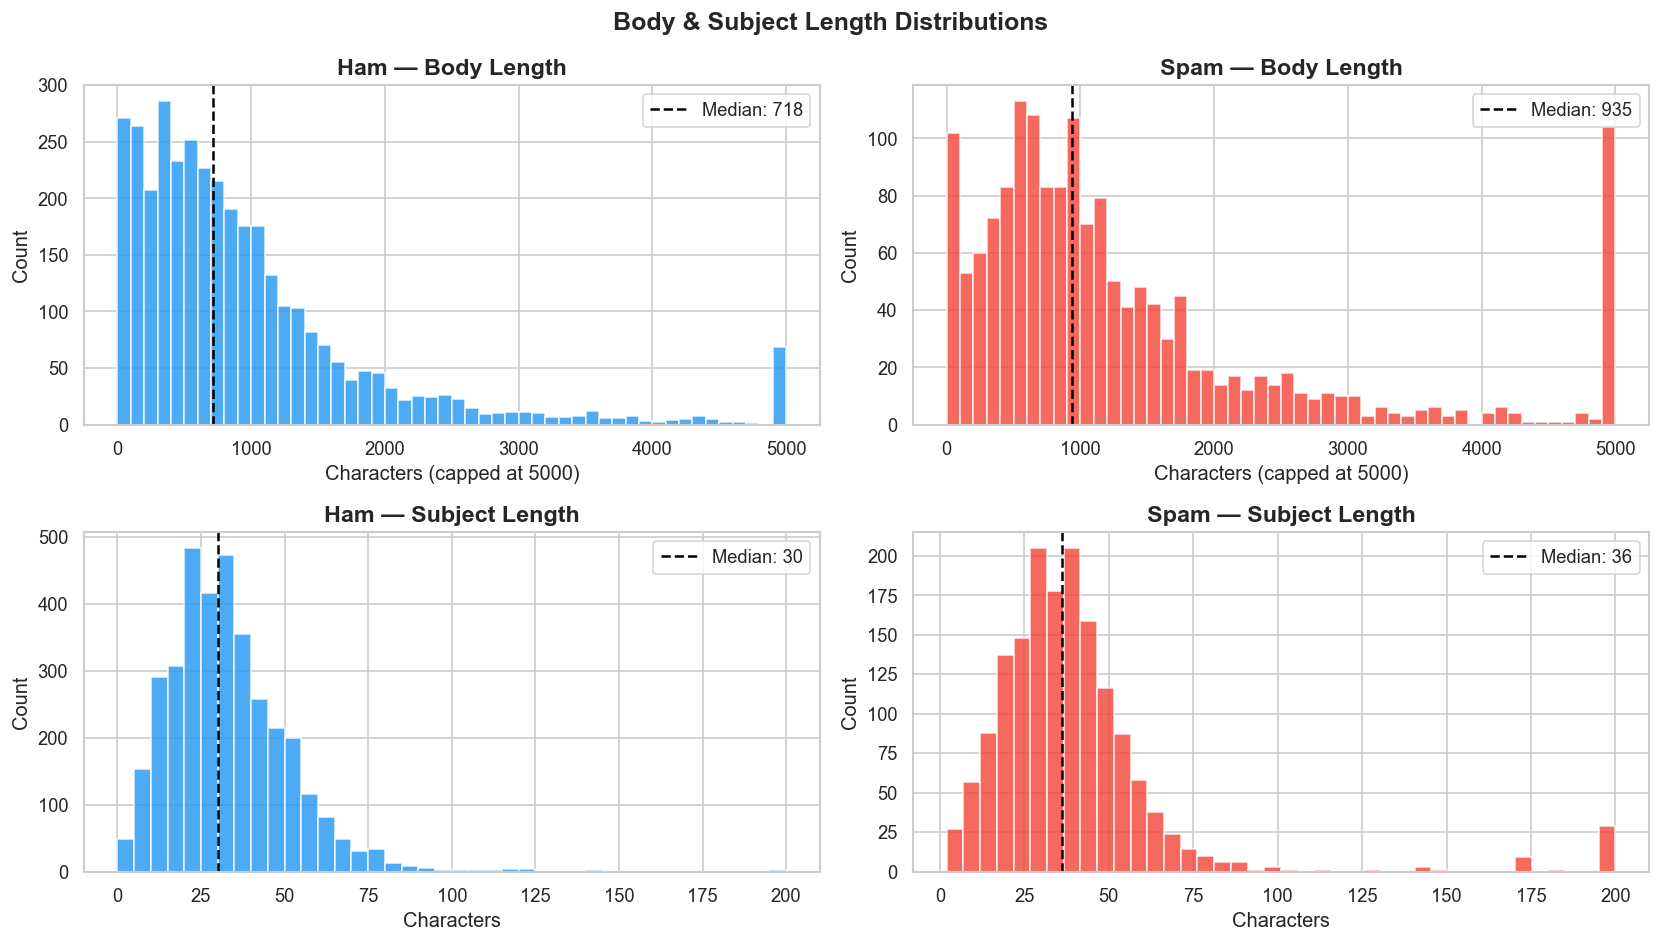

[ 2026-05-15 03:28:59,401 ] [ INFO ] [ 1783651524.py:26 ] 🚀 ✅ Body & Subject Length plot rendered


In [43]:
logger.info("📏 Plotting Body & Subject Length Distributions")
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = {0: '#2196F3', 1: '#F44336'}

for ax, (cls, label) in zip(axes[0], [(0, 'Ham'), (1, 'Spam')]):
    data = df[df['target'] == cls]['body_len'].clip(upper=5000)
    ax.hist(data, bins=50, color=colors[cls], alpha=0.8, edgecolor='white')
    ax.axvline(data.median(), color='black', linestyle='--', label=f'Median: {data.median():.0f}')
    ax.set_title(f'{label} — Body Length')
    ax.set_xlabel('Characters (capped at 5000)')
    ax.set_ylabel('Count')
    ax.legend()

for ax, (cls, label) in zip(axes[1], [(0, 'Ham'), (1, 'Spam')]):
    data = df[df['target'] == cls]['subject_len'].dropna().clip(upper=200)
    ax.hist(data, bins=40, color=colors[cls], alpha=0.8, edgecolor='white')
    ax.axvline(data.median(), color='black', linestyle='--', label=f'Median: {data.median():.0f}')
    ax.set_title(f'{label} — Subject Length')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Body & Subject Length Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
logger.info("✅ Body & Subject Length plot rendered")


## 6. Numerical Features — Spam vs Ham Comparison

[ 2026-05-15 03:28:59,407 ] [ INFO ] [ 1290553107.py:1 ] 🚀 📈 Plotting Numerical Feature Distributions


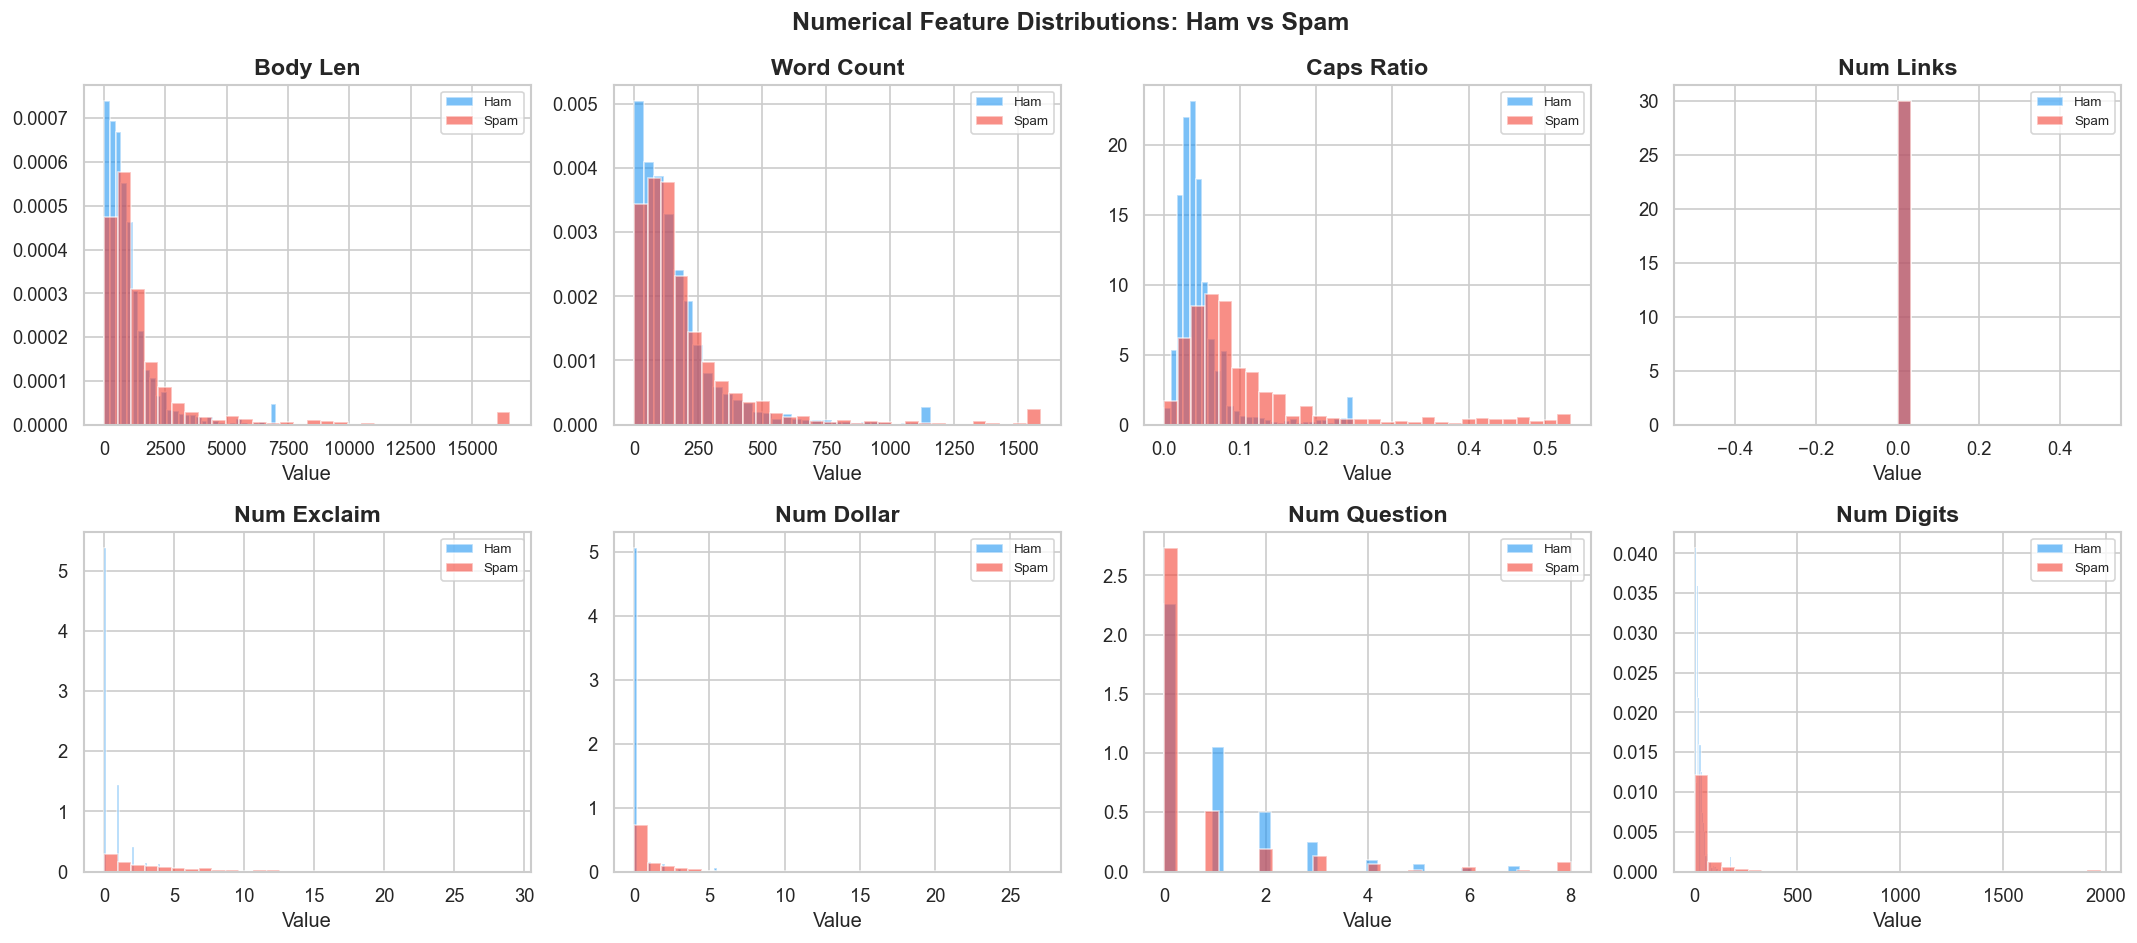

[ 2026-05-15 03:29:00,017 ] [ INFO ] [ 1290553107.py:22 ] 🚀 ✅ Numerical feature distribution plot rendered


In [44]:
logger.info("📈 Plotting Numerical Feature Distributions")
num_feats = ['body_len', 'word_count', 'caps_ratio', 'num_links',
             'num_exclaim', 'num_dollar', 'num_question', 'num_digits']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(num_feats):
    for cls, label, color in [(0,'Ham','#2196F3'), (1,'Spam','#F44336')]:
        data = df[df['target'] == cls][feat].dropna()
        # clip outliers
        upper = data.quantile(0.99)
        data  = data.clip(upper=upper)
        axes[i].hist(data, bins=30, alpha=0.6, label=label, color=color, density=True)
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')

plt.suptitle('Numerical Feature Distributions: Ham vs Spam', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
logger.info("✅ Numerical feature distribution plot rendered")


## 7. Binary Feature Analysis

[ 2026-05-15 03:29:00,050 ] [ INFO ] [ 1022777738.py:1 ] 🚀 🔢 Plotting Binary Feature Analysis


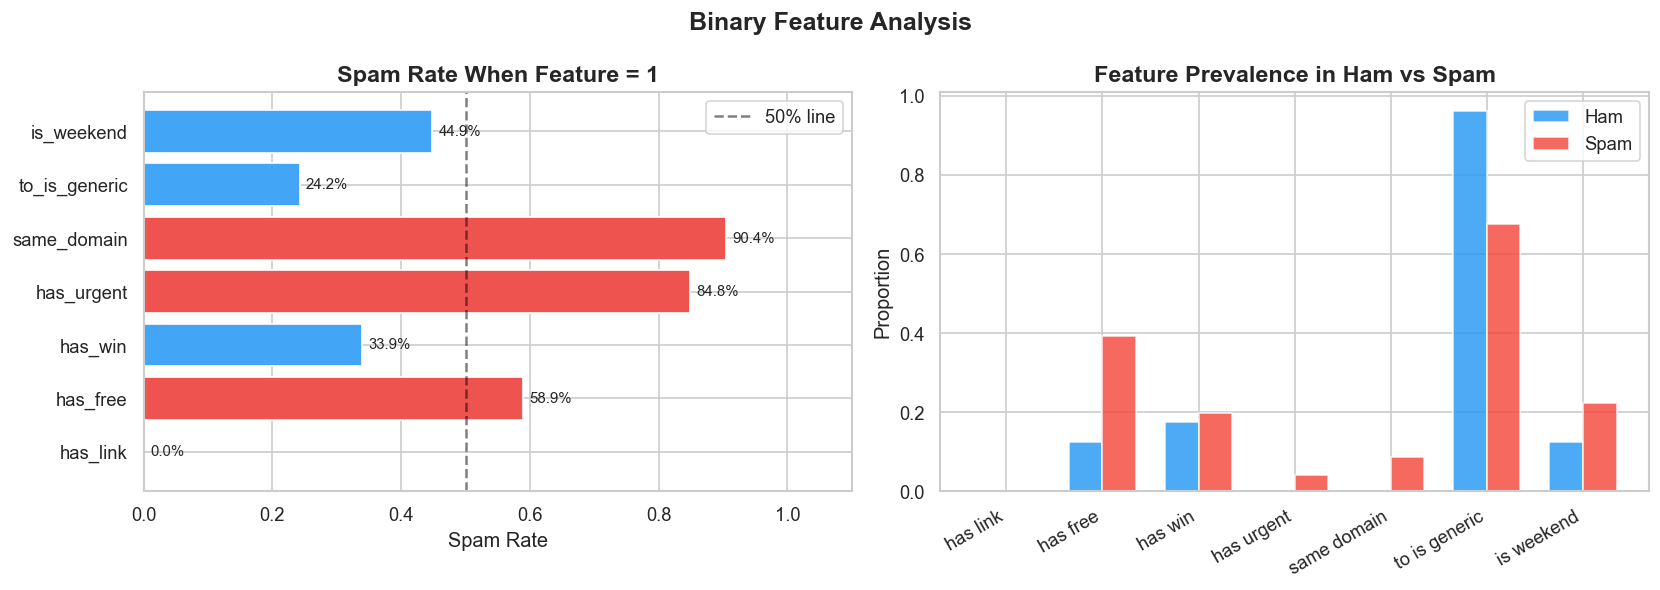

[ 2026-05-15 03:29:00,231 ] [ INFO ] [ 1022777738.py:40 ] 🚀 ✅ Binary feature analysis complete | Features: ['has_link', 'has_free', 'has_win', 'has_urgent', 'same_domain', 'to_is_generic', 'is_weekend']


In [45]:
logger.info("🔢 Plotting Binary Feature Analysis")
binary_feats = ['has_link', 'has_free', 'has_win', 'has_urgent',
                'same_domain', 'to_is_generic', 'is_weekend']

spam_rates = []
for f in binary_feats:
    rate = df.groupby(f)['target'].mean().get(1, 0)  # spam rate when feature=1
    spam_rates.append(rate)

palette = ['#EF5350' if r > 0.5 else '#42A5F5' for r in spam_rates]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spam rate when feature is present
axes[0].barh(binary_feats, spam_rates, color=palette)
axes[0].axvline(0.5, color='black', linestyle='--', alpha=0.5, label='50% line')
for i, v in enumerate(spam_rates):
    axes[0].text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=9)
axes[0].set_title('Spam Rate When Feature = 1')
axes[0].set_xlabel('Spam Rate')
axes[0].set_xlim(0, 1.1)
axes[0].legend()

# Prevalence in spam vs ham
spam_prev = df[df['target']==1][binary_feats].mean()
ham_prev  = df[df['target']==0][binary_feats].mean()

x = np.arange(len(binary_feats))
w = 0.35
axes[1].bar(x - w/2, ham_prev, w, label='Ham', color='#2196F3', alpha=0.8)
axes[1].bar(x + w/2, spam_prev, w, label='Spam', color='#F44336', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f.replace('_',' ') for f in binary_feats], rotation=30, ha='right')
axes[1].set_title('Feature Prevalence in Ham vs Spam')
axes[1].set_ylabel('Proportion')
axes[1].legend()

plt.suptitle('Binary Feature Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
logger.info(f"✅ Binary feature analysis complete | Features: {binary_feats}")


## 8. Correlation Heatmap

[ 2026-05-15 03:29:00,237 ] [ INFO ] [ 3950342574.py:1 ] 🚀 🔥 Plotting Correlation Heatmap


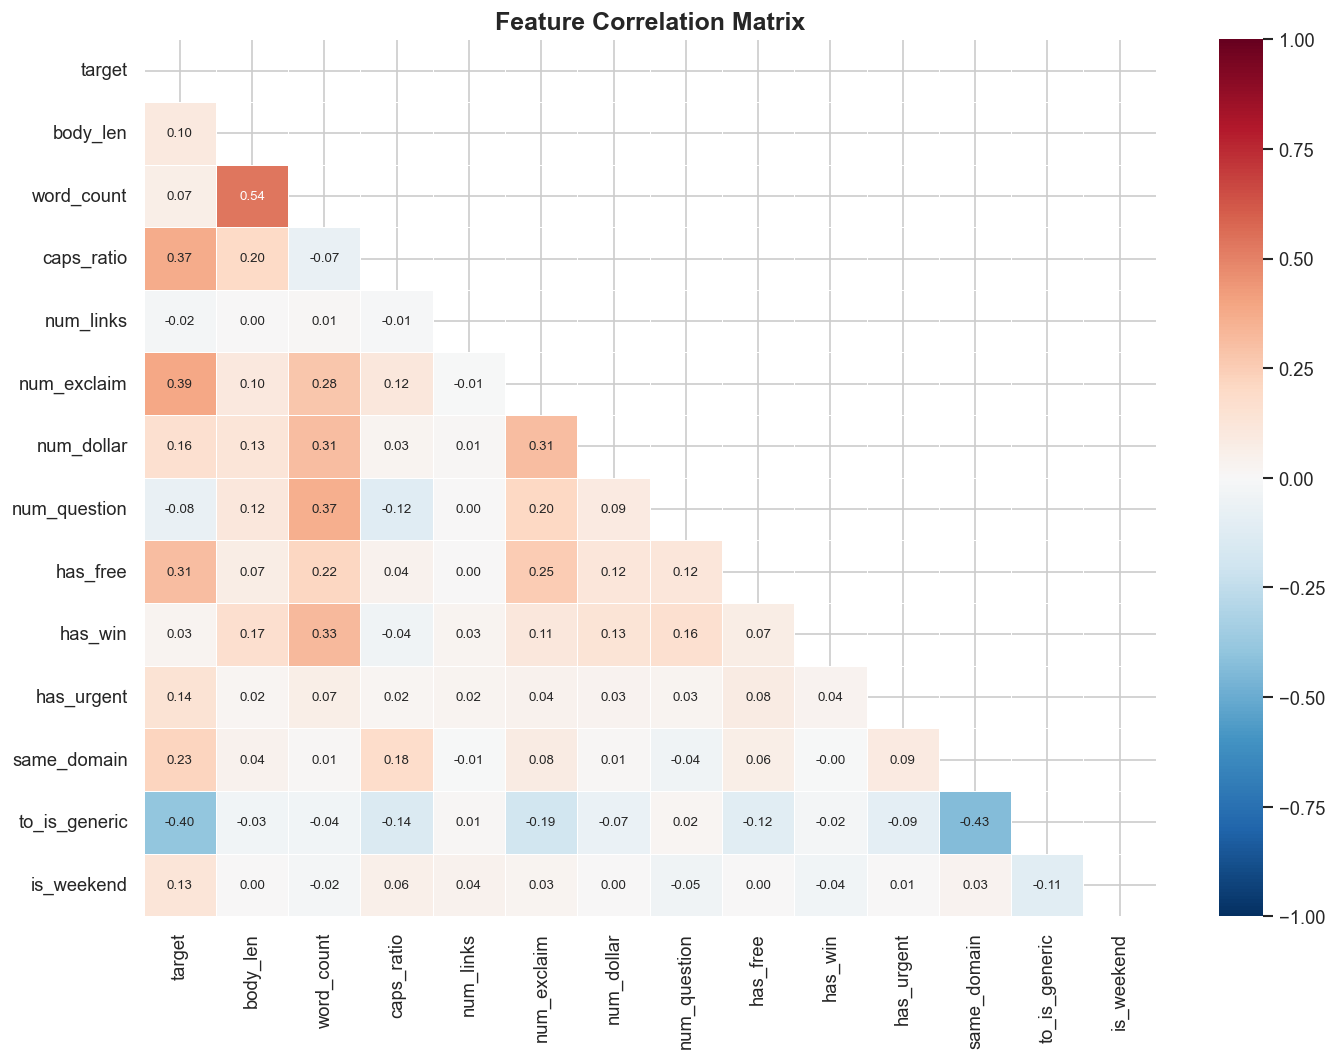

[ 2026-05-15 03:29:00,435 ] [ INFO ] [ 3950342574.py:16 ] 🚀 ✅ Correlation heatmap rendered


In [46]:
logger.info("🔥 Plotting Correlation Heatmap")
corr_cols = ['target','body_len','word_count','caps_ratio','num_links',
             'num_exclaim','num_dollar','num_question','has_free',
             'has_win','has_urgent','same_domain','to_is_generic','is_weekend']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
logger.info("✅ Correlation heatmap rendered")


## 9. Top Correlations with Target

[ 2026-05-15 03:29:00,442 ] [ INFO ] [ 482614537.py:1 ] 🚀 🎯 Plotting Top Feature Correlations with Target


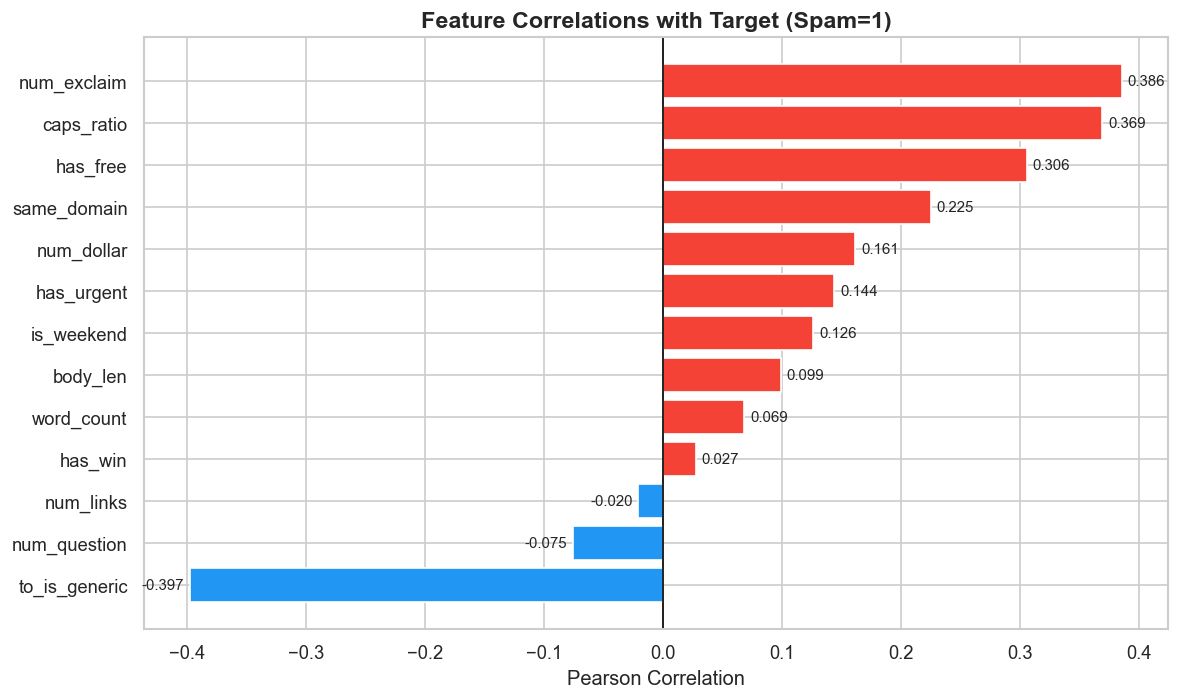

[ 2026-05-15 03:29:00,541 ] [ INFO ] [ 482614537.py:17 ] 🚀 ✅ Top positive corr: num_exclaim (0.386) | Top negative: to_is_generic (-0.397)


In [47]:
logger.info("🎯 Plotting Top Feature Correlations with Target")
target_corr = corr['target'].drop('target').sort_values()
colors = ['#F44336' if v > 0 else '#2196F3' for v in target_corr]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
for bar, v in zip(bars, target_corr.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_title('Feature Correlations with Target (Spam=1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()
top_pos = target_corr[target_corr > 0].idxmax()
top_neg = target_corr[target_corr < 0].idxmin()
logger.info(f"✅ Top positive corr: {top_pos} ({target_corr[top_pos]:.3f}) | Top negative: {top_neg} ({target_corr[top_neg]:.3f})")


## 10. Day of Week Analysis

[ 2026-05-15 03:29:00,548 ] [ INFO ] [ 311189236.py:1 ] 🚀 📅 Plotting Day-of-Week Email Patterns


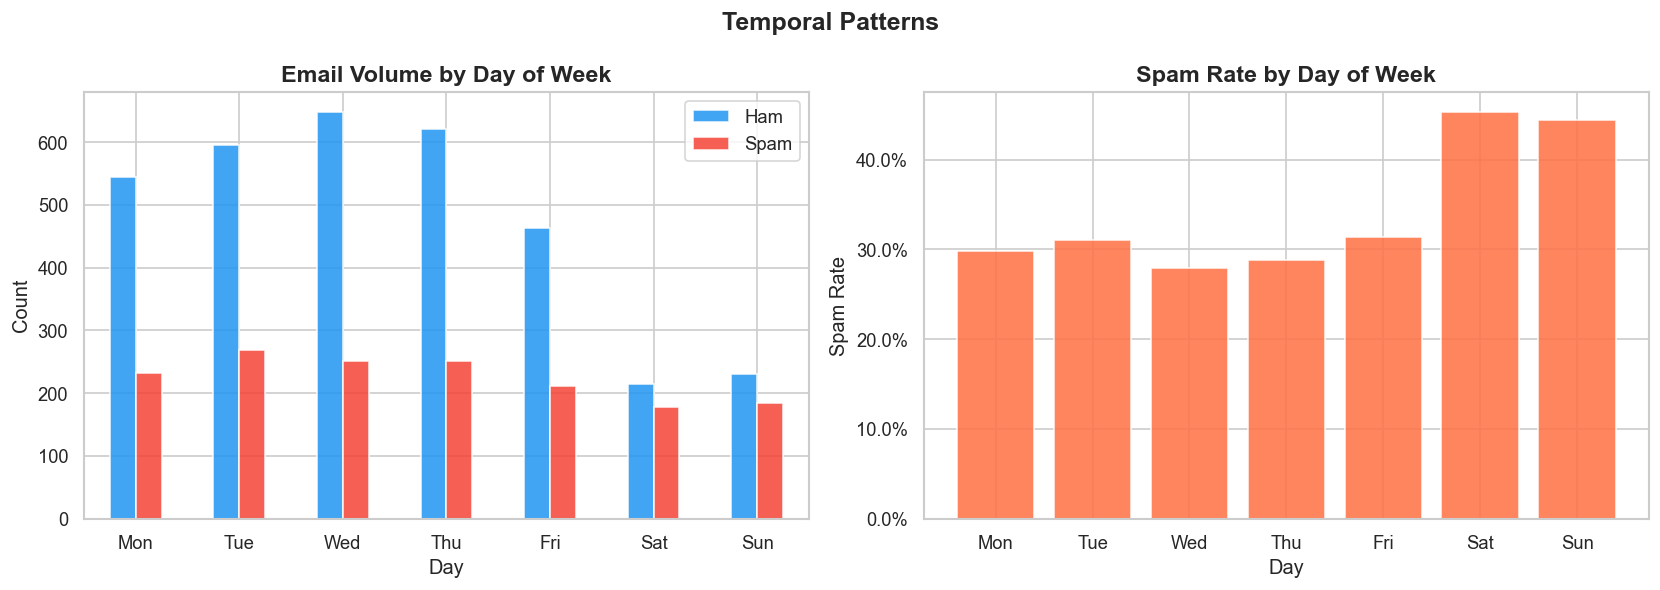

[ 2026-05-15 03:29:00,697 ] [ INFO ] [ 311189236.py:29 ] 🚀 ✅ Day-of-week temporal analysis plot rendered


In [48]:
logger.info("📅 Plotting Day-of-Week Email Patterns")
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_df = df[df['day_of_week'].notna()].copy()
day_df['day_of_week'] = pd.Categorical(day_df['day_of_week'], categories=day_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Email count by day
day_counts = day_df.groupby(['day_of_week','target']).size().unstack(fill_value=0)
day_counts.plot(kind='bar', ax=axes[0], color=['#2196F3','#F44336'], alpha=0.85,
                edgecolor='white')
axes[0].set_title('Email Volume by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Count')
axes[0].legend(['Ham','Spam'])
axes[0].tick_params(axis='x', rotation=0)

# Spam rate by day
spam_rate_day = day_df.groupby('day_of_week')['target'].mean()
axes[1].bar(spam_rate_day.index, spam_rate_day.values, color='#FF7043', alpha=0.85, edgecolor='white')
axes[1].set_title('Spam Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Spam Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Temporal Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
logger.info("✅ Day-of-week temporal analysis plot rendered")


## 11. Top Sender Domains

[ 2026-05-15 03:29:00,743 ] [ INFO ] [ 3244544589.py:1 ] 🚀 🌐 Plotting Top Sender Domains


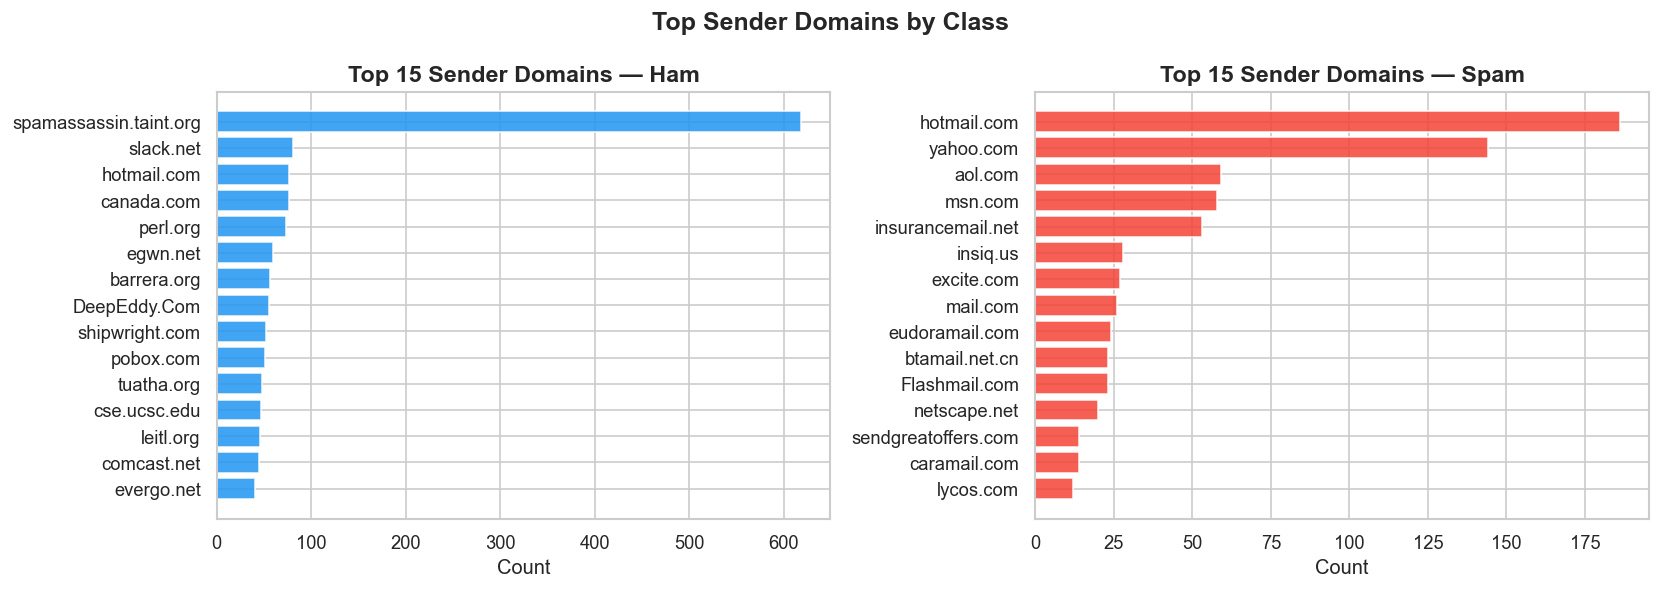

[ 2026-05-15 03:29:00,908 ] [ INFO ] [ 3244544589.py:15 ] 🚀 ✅ Sender domain analysis plot rendered


In [49]:
logger.info("🌐 Plotting Top Sender Domains")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cls, label, color) in zip(axes, [(0,'Ham','#2196F3'),(1,'Spam','#F44336')]):
    domains = (df[df['target']==cls]['from_domain']
               .replace('unknown', np.nan).dropna()
               .value_counts().head(15))
    ax.barh(domains.index[::-1], domains.values[::-1], color=color, alpha=0.85)
    ax.set_title(f'Top 15 Sender Domains — {label}')
    ax.set_xlabel('Count')

plt.suptitle('Top Sender Domains by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
logger.info("✅ Sender domain analysis plot rendered")


## 12. Word Clouds — Ham vs Spam Body

[ 2026-05-15 03:29:00,914 ] [ INFO ] [ 1758970343.py:1 ] 🚀 ☁️  Generating Word Clouds (Ham vs Spam)


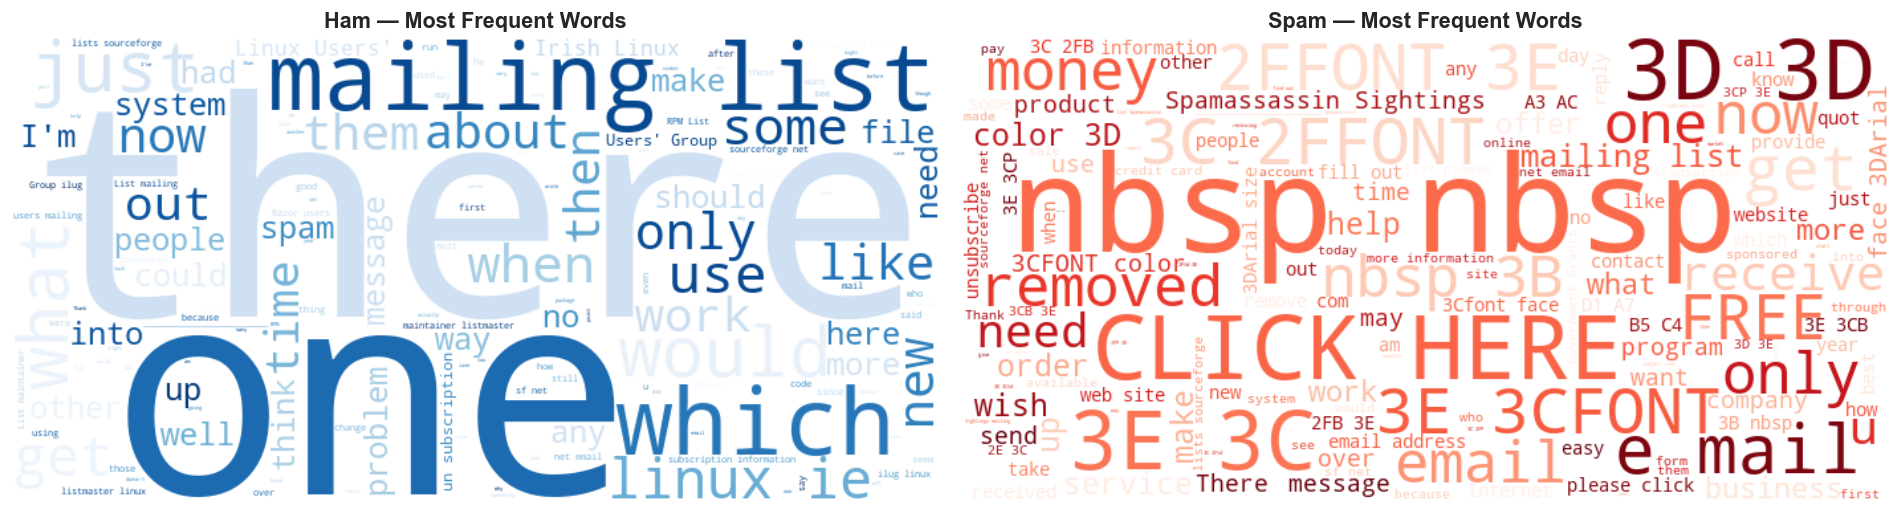

[ 2026-05-15 03:29:02,988 ] [ INFO ] [ 1758970343.py:21 ] 🚀 ✅ Word clouds rendered


In [50]:
logger.info("☁️  Generating Word Clouds (Ham vs Spam)")
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
STOPWORDS = {'the','a','an','and','or','to','of','in','is','it','this','that',
             'for','with','on','are','was','be','at','as','by','from','have',
             'not','but','we','you','your','our','they','their','has','will',
             'can','all','also','been','do','does','i','my','me','its','if','so'}

for ax, (cls, label, color) in zip(axes, [(0,'Ham','Blues'),(1,'Spam','Reds')]):
    text = ' '.join(df[df['target']==cls]['body'].dropna().astype(str).tolist())
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=color, stopwords=STOPWORDS,
                   max_words=150).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label} — Most Frequent Words', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
logger.info("✅ Word clouds rendered")


## 13. Subject Line Analysis

[ 2026-05-15 03:29:03,009 ] [ INFO ] [ 3124210042.py:1 ] 🚀 📝 Plotting Subject Line Vocabulary Analysis


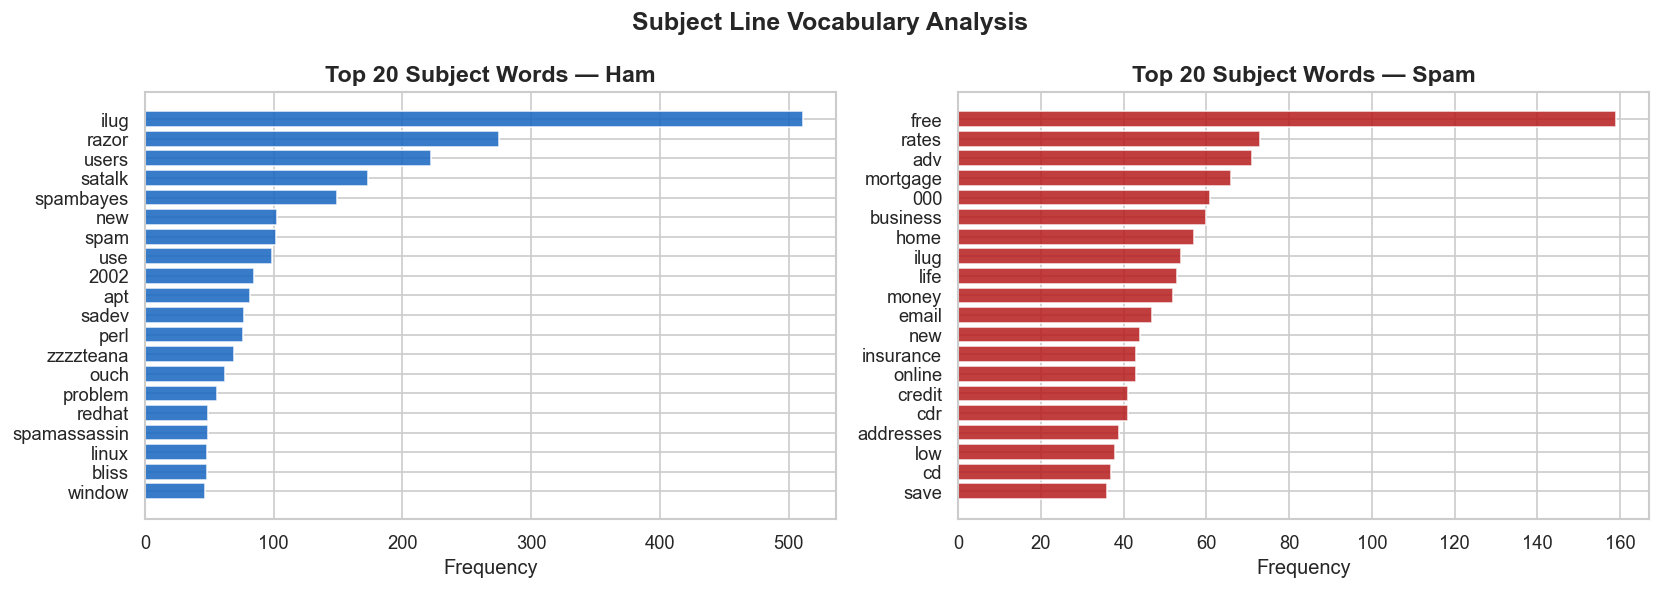

[ 2026-05-15 03:29:03,213 ] [ INFO ] [ 3124210042.py:21 ] 🚀 ✅ Subject line analysis plot rendered


In [51]:
logger.info("📝 Plotting Subject Line Vocabulary Analysis")
# Top 20 keywords in spam subjects
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cls, label, color) in zip(axes, [(0,'Ham','#1565C0'),(1,'Spam','#B71C1C')]):
    subjects = df[df['target']==cls]['subject'].dropna().astype(str)
    cv = CountVectorizer(max_features=20, stop_words='english', ngram_range=(1,1))
    cv.fit_transform(subjects)
    freq = dict(zip(cv.get_feature_names_out(),
                    cv.transform(subjects).toarray().sum(axis=0)))
    freq_s = pd.Series(freq).sort_values(ascending=True)
    ax.barh(freq_s.index, freq_s.values, color=color, alpha=0.85)
    ax.set_title(f'Top 20 Subject Words — {label}')
    ax.set_xlabel('Frequency')

plt.suptitle('Subject Line Vocabulary Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
logger.info("✅ Subject line analysis plot rendered")


## 14. Outlier Detection (Box Plots)

[ 2026-05-15 03:29:03,219 ] [ INFO ] [ 3036601203.py:1 ] 🚀 📦 Plotting Outlier Detection Box Plots


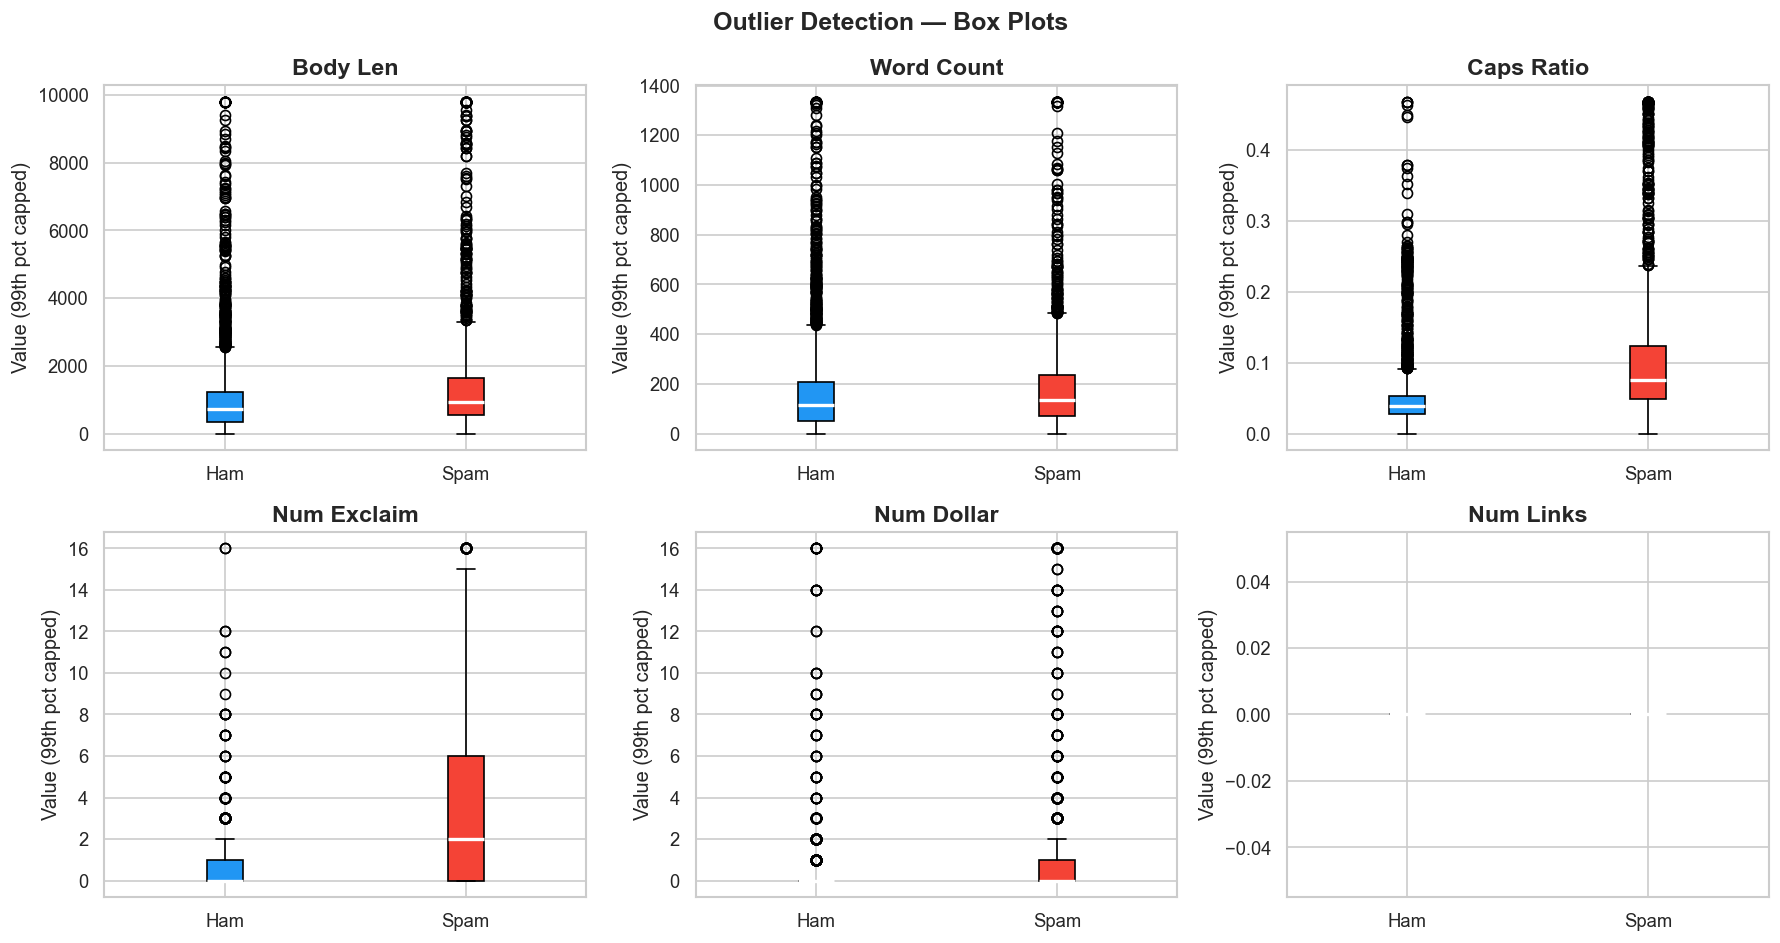

[ 2026-05-15 03:29:03,501 ] [ INFO ] [ 3036601203.py:19 ] 🚀 ✅ Outlier detection box plots rendered


In [52]:
logger.info("📦 Plotting Outlier Detection Box Plots")
box_feats = ['body_len','word_count','caps_ratio','num_exclaim','num_dollar','num_links']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(box_feats):
    data = [df[df['target']==cls][feat].dropna().clip(upper=df[feat].quantile(0.99)).values
            for cls in [0, 1]]
    bp = axes[i].boxplot(data, labels=['Ham','Spam'], patch_artist=True,
                         medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#F44336')
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].set_ylabel('Value (99th pct capped)')

plt.suptitle('Outlier Detection — Box Plots', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
logger.info("✅ Outlier detection box plots rendered")


## 15. EDA Summary Insights

In [53]:
# ─────────────────────────────────────────
# EDA SUMMARY REPORT
# ─────────────────────────────────────────

logger.info("📊 Generating EDA Summary Report")

summary_cols = [
    'body_len',
    'subject_len',
    'num_links',
    'caps_ratio',
    'num_exclamations',
    'num_dollar',
    'target'
]

# Statistical Summary
summary_stats = df[summary_cols].describe()

logger.info(f"\n📈 Statistical Summary:\n{summary_stats}")

# ─────────────────────────────────────────
# Dataset Split
# ─────────────────────────────────────────
spam_df = df[df['target'] == 1]
ham_df  = df[df['target'] == 0]

# ─────────────────────────────────────────
# Console Summary
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("           EDA KEY FINDINGS SUMMARY")
print("=" * 60)

# Dataset Overview
print("\n📊 DATASET OVERVIEW")
print("-" * 60)

print(f"Total Emails        : {len(df):,}")
print(f"Ham Emails          : {len(ham_df):,} ({len(ham_df)/len(df):.1%})")
print(f"Spam Emails         : {len(spam_df):,} ({len(spam_df)/len(df):.1%})")

# Body Length
print("\n📏 BODY LENGTH ANALYSIS")
print("-" * 60)

print(f"Spam Median Length  : {spam_df['body_len'].median():,.0f} chars")
print(f"Ham Median Length   : {ham_df['body_len'].median():,.0f} chars")

# Links
print("\n🔗 LINK ANALYSIS")
print("-" * 60)

print(f"Spam With Links     : {spam_df['has_link'].mean():.1%}")
print(f"Ham With Links      : {ham_df['has_link'].mean():.1%}")

# Free Word
print('\n💰 "FREE" WORD USAGE')
print("-" * 60)

print(f'Spam Emails         : {spam_df["has_free"].mean():.1%}')
print(f'Ham Emails          : {ham_df["has_free"].mean():.1%}')

# Win Word
print('\n🚨 "WIN/WINNER" WORD USAGE')
print("-" * 60)

print(f'Spam Emails         : {spam_df["has_win"].mean():.1%}')
print(f'Ham Emails          : {ham_df["has_win"].mean():.1%}')

# Dollar Sign Analysis
print("\n💲 DOLLAR SIGN ANALYSIS")
print("-" * 60)

print(f"Spam Avg Dollar     : {spam_df['num_dollar'].mean():.2f}")
print(f"Ham Avg Dollar      : {ham_df['num_dollar'].mean():.2f}")

# Weekend Analysis
print("\n📅 WEEKEND EMAIL ANALYSIS")
print("-" * 60)

print(f"Spam on Weekend     : {spam_df['is_weekend'].mean():.1%}")
print(f"Ham on Weekend      : {ham_df['is_weekend'].mean():.1%}")

print("\n" + "=" * 60)

logger.info("🏁 EDA Completed Successfully ✅")

[ 2026-05-15 03:29:03,509 ] [ INFO ] [ 1228816139.py:5 ] 🚀 📊 Generating EDA Summary Report
[ 2026-05-15 03:29:03,517 ] [ INFO ] [ 1228816139.py:20 ] 🚀 
📈 Statistical Summary:
            body_len  subject_len    num_links   caps_ratio  num_exclamations  \
count    5163.000000  5163.000000  5163.000000  5163.000000       5163.000000   
mean     1329.712377    37.612628     0.001743     0.070113          1.439667   
std      4136.543821    89.020897     0.057361     0.082628          3.911258   
min         0.000000     0.000000     0.000000     0.000000          0.000000   
25%       394.000000    22.000000     0.000000     0.030511          0.000000   
50%       785.000000    32.000000     0.000000     0.044622          0.000000   
75%      1354.500000    44.000000     0.000000     0.074048          1.000000   
max    228377.000000  5293.000000     3.000000     0.802789         81.000000   

        num_dollar       target  
count  5163.000000  5163.000000  
mean      0.731939     0.31


           EDA KEY FINDINGS SUMMARY

📊 DATASET OVERVIEW
------------------------------------------------------------
Total Emails        : 5,163
Ham Emails          : 3,550 (68.8%)
Spam Emails         : 1,613 (31.2%)

📏 BODY LENGTH ANALYSIS
------------------------------------------------------------
Spam Median Length  : 935 chars
Ham Median Length   : 718 chars

🔗 LINK ANALYSIS
------------------------------------------------------------
Spam With Links     : 0.0%
Ham With Links      : 0.2%

💰 "FREE" WORD USAGE
------------------------------------------------------------
Spam Emails         : 39.2%
Ham Emails          : 12.5%

🚨 "WIN/WINNER" WORD USAGE
------------------------------------------------------------
Spam Emails         : 19.9%
Ham Emails          : 17.6%

💲 DOLLAR SIGN ANALYSIS
------------------------------------------------------------
Spam Avg Dollar     : 1.70
Ham Avg Dollar      : 0.29

📅 WEEKEND EMAIL ANALYSIS
------------------------------------------------------